密度估计

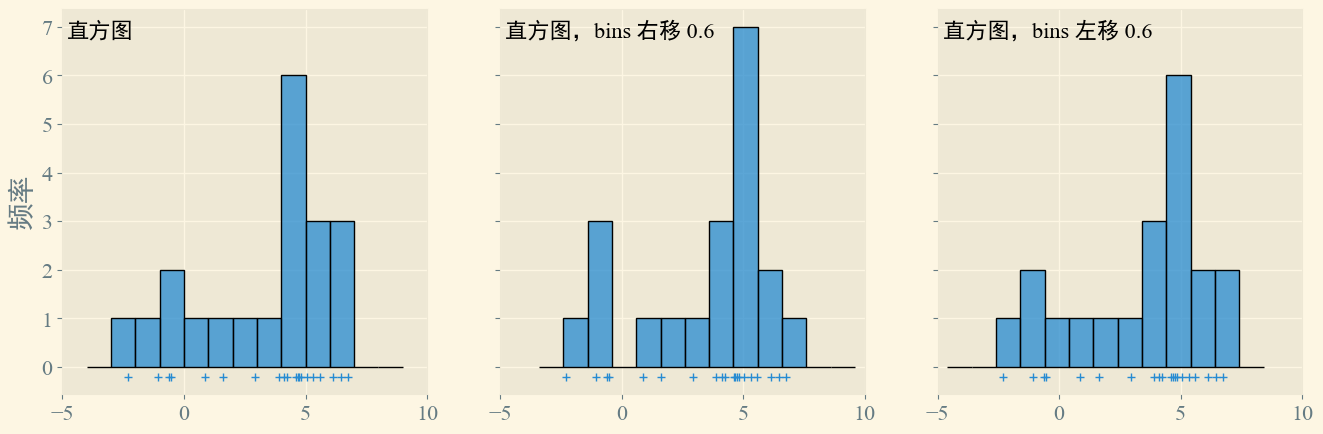

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st

plt.rcParams.update({
    "font.family": ["Times New Roman", "SimHei"],
    "axes.unicode_minus": True,
    "font.size": 16,
})

np.random.seed(1)
N, shift = 20, 0.6
X = np.concatenate((st.norm.rvs(0, 1, size=int(0.3 * N)), st.norm.rvs(5, 1, size=int(0.7 * N))))
bins = np.linspace(-4, 9, 14)

with plt.style.context('Solarize_Light2'):

    fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    x, y = -4.8, 6.8
    sns.histplot(X, bins=bins, stat="frequency", ax=axs[0])
    axs[0].text(x, y, "直方图")
    axs[0].set_ylabel("频率", fontsize=20)
    sns.histplot(X, bins=bins + shift, stat="frequency", ax=axs[1])
    axs[1].text(x, y, f"直方图，bins 右移 {shift}")
    sns.histplot(X, bins=bins - shift, stat="frequency", ax=axs[2])
    axs[2].text(x, y, f"直方图，bins 左移 {shift}")

    for ax in axs:
        ax.plot(X, np.full(len(X), -0.2), '+')
        ax.set_xlim(-5, 10)

    plt.show()


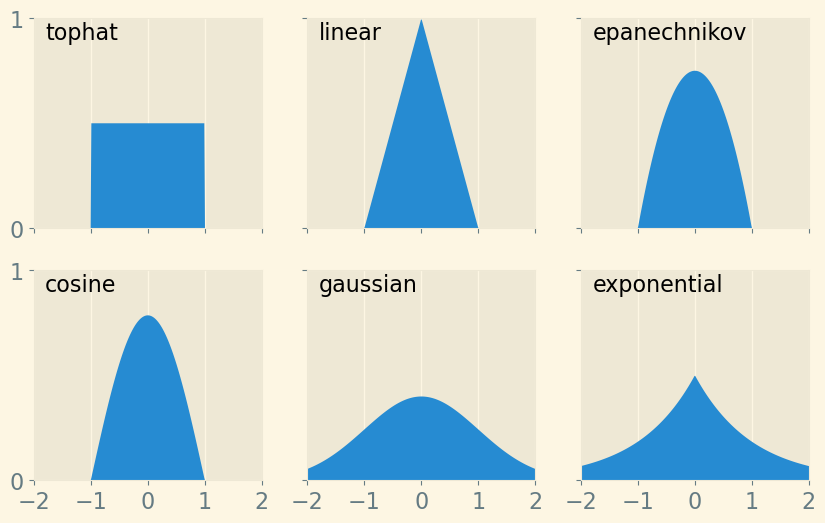

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KernelDensity

plt.rcParams.update({
    "axes.unicode_minus": True,
    "font.size": 16,
})

X_plot = np.linspace(-6, 6, 1000)[:, None]
X_src = np.zeros((1, 1))

with plt.style.context('Solarize_Light2'):

    fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 6))

    for i, kernel in enumerate(['tophat', 'linear', 'epanechnikov', 'cosine', 'gaussian', 'exponential']):
        ax = axs.ravel()[i]
        log_dens = KernelDensity(kernel=kernel).fit(X_src).score_samples(X_plot)
        ax.fill(X_plot[:, 0], np.exp(log_dens))
        ax.text(-1.8, 0.9, kernel)
        ax.xaxis.set_major_locator(plt.MultipleLocator(1))
        ax.yaxis.set_major_locator(plt.MultipleLocator(1))
        ax.set_xlim(-2, 2)
        ax.set_ylim(0, 1)

    plt.show()

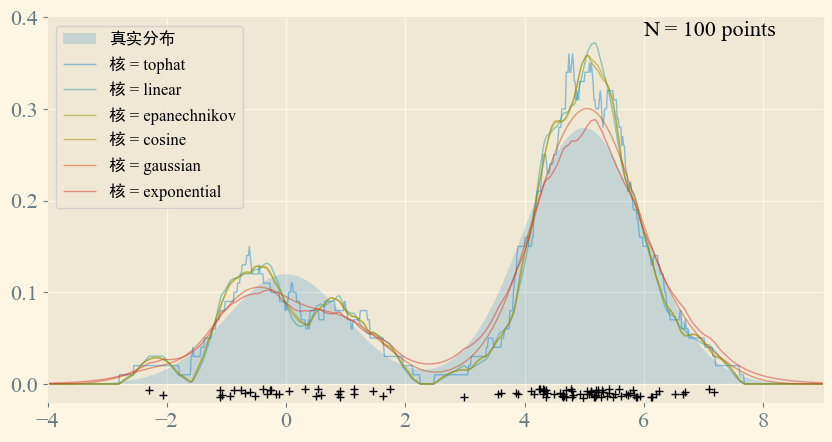

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns
from sklearn.neighbors import KernelDensity

plt.rcParams.update({
    "font.family": ["Times New Roman", "SimHei"],
    "axes.unicode_minus": True,
    'legend.fontsize': '12',
})

np.random.seed(1)
N = 100  # 100个样本
X = np.concatenate((st.norm.rvs(0, 1, int(0.3 * N)),
                    st.norm.rvs(5, 1, int(0.7 * N))))[:, np.newaxis]

X_plot = np.linspace(-5, 10, 1000)[:, np.newaxis]

true_dens = (0.3 * st.norm(0, 1).pdf(X_plot[:, 0])
             + 0.7 * st.norm(5, 1).pdf(X_plot[:, 0]))

with plt.style.context('Solarize_Light2'):

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill(X_plot[:, 0], true_dens, alpha=0.2, label='真实分布')

    for kernel in ['tophat', 'linear', 'epanechnikov', 'cosine', 'gaussian', 'exponential']:
        log_dens = KernelDensity(kernel=kernel, bandwidth=0.5).fit(X).score_samples(X_plot)
        ax = sns.lineplot(x=X_plot[:, 0], y=np.exp(log_dens), lw=1, ls='-', alpha=0.5, label=f"核 = {kernel}")

    ax.text(6, 0.38, "N = {0} points".format(N))
    ax.legend(loc='upper left')
    ax.plot(X[:, 0], -0.005 - 0.01 * st.uniform.rvs(size=X.shape[0]), '+k')
    ax.set_xlim(-4, 9)
    ax.set_ylim(-0.02, 0.4)

    plt.show()